In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PATH = "../data/raw/AEP_hourly.csv"

df = pd.read_csv(PATH)

df.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  121273 non-null  str    
 1   AEP_MW    121273 non-null  float64
dtypes: float64(1), str(1)
memory usage: 4.0 MB


In [8]:
df.describe()

,AEP_MW
count,121273.000000
mean,15499.513717
std,2591.399065
min,9581.000000
25%,13630.000000
50%,15310.000000
75%,17200.000000
max,25695.000000


In [9]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

df = df.sort_values("Datetime").reset_index(drop=True)

df.head()

,Datetime,AEP_MW
0,2004-10-01 01:00:00,12379.0
1,2004-10-01 02:00:00,11935.0
2,2004-10-01 03:00:00,11692.0
3,2004-10-01 04:00:00,11597.0
4,2004-10-01 05:00:00,11681.0


In [10]:
print("Rows:", len(df))
print("Start:", df["Datetime"].min())
print("End:", df["Datetime"].max())
print("Duplicates:", df["Datetime"].duplicated().sum())
print("Missing values:")
print(df.isna().sum())

Rows: 121273
Start: 2004-10-01 01:00:00
End: 2018-08-03 00:00:00
Duplicates: 4
Missing values:
Datetime    0
AEP_MW      0
dtype: int64


In [11]:
time_diff = df["Datetime"].diff().value_counts()

time_diff.head(10)

Datetime
0 days 01:00:00    121241
0 days 02:00:00        27
0 days 00:00:00         4
Name: count, dtype: int64

In [12]:
invalid_intervals = df.loc[
    df["Datetime"].diff() != pd.Timedelta(hours=1),
    ["Datetime"]
]

invalid_intervals.head(20)

,Datetime
0,2004-10-01 01:00:00
721,2004-10-31 03:00:00
4417,2005-04-03 04:00:00
9455,2005-10-30 03:00:00
13151,2006-04-02 04:00:00
18189,2006-10-29 03:00:00
21381,2007-03-11 04:00:00
27091,2007-11-04 03:00:00
30115,2008-03-09 04:00:00
35825,2008-11-02 03:00:00


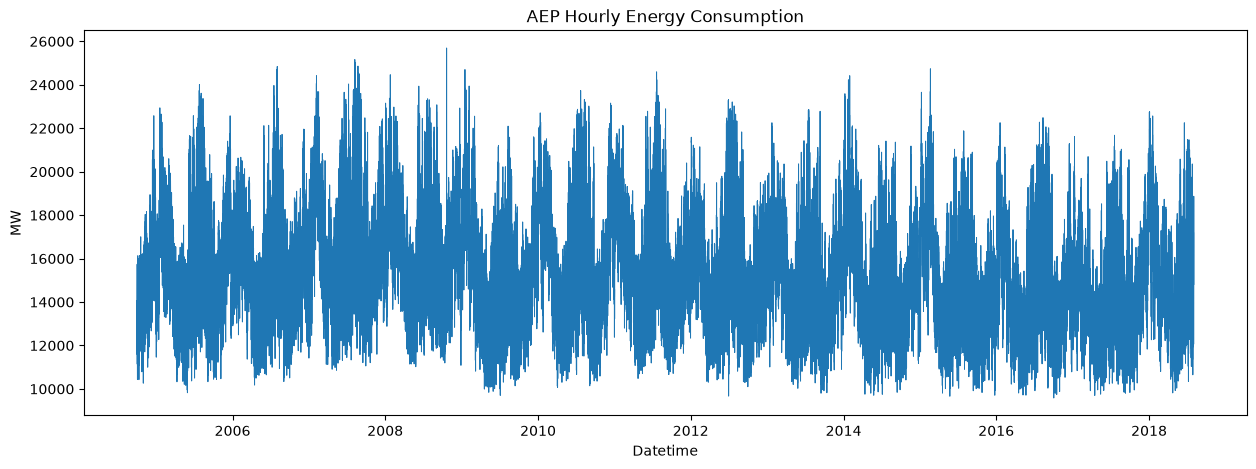

In [13]:
plt.figure(figsize=(15, 5))

plt.plot(
    df["Datetime"],
    df["AEP_MW"],
    linewidth=0.7
)

plt.title("AEP Hourly Energy Consumption")
plt.xlabel("Datetime")
plt.ylabel("MW")

plt.show()

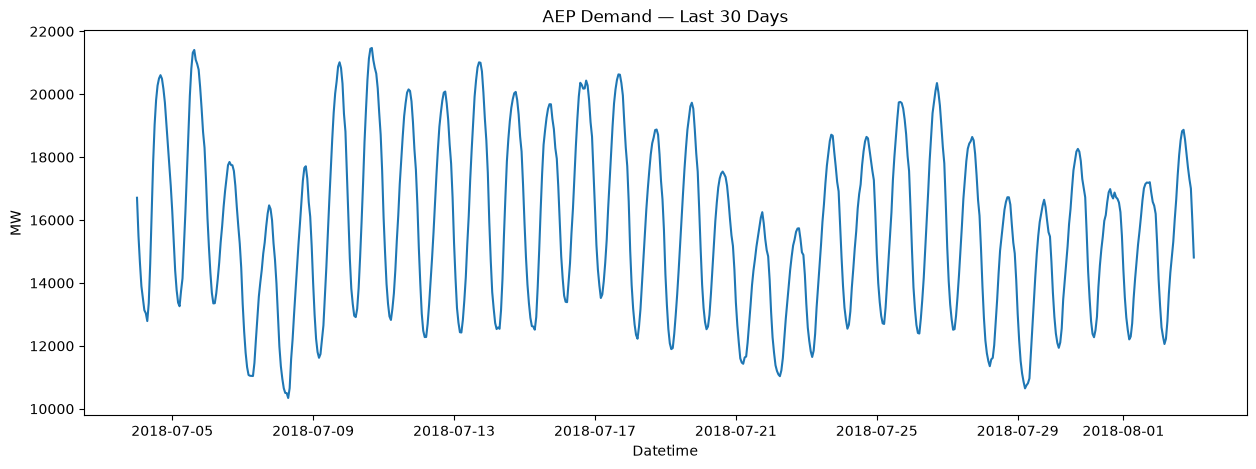

In [14]:
last_30_days = df[
    df["Datetime"] >= df["Datetime"].max() - pd.Timedelta(days=30)
]

plt.figure(figsize=(15, 5))

plt.plot(
    last_30_days["Datetime"],
    last_30_days["AEP_MW"]
)

plt.title("AEP Demand — Last 30 Days")
plt.xlabel("Datetime")
plt.ylabel("MW")

plt.show()

In [15]:
df["hour"] = df["Datetime"].dt.hour
df["day_of_week"] = df["Datetime"].dt.dayofweek

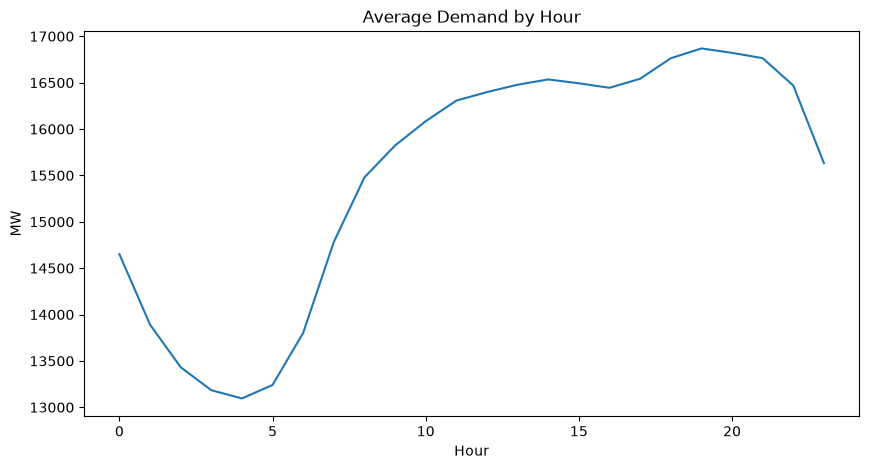

In [16]:
hourly_profile = df.groupby("hour")["AEP_MW"].mean()

hourly_profile.plot(figsize=(10, 5))

plt.title("Average Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("MW")

plt.show()

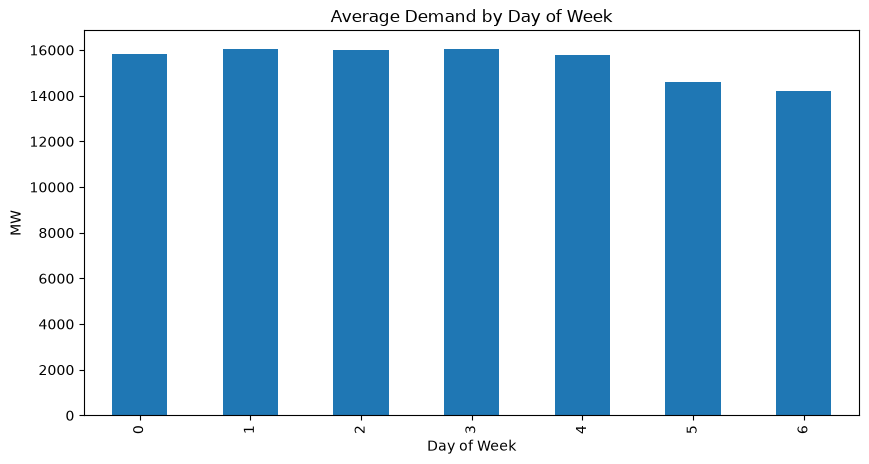

In [17]:
weekly_profile = df.groupby("day_of_week")["AEP_MW"].mean()

weekly_profile.plot(kind="bar", figsize=(10, 5))

plt.title("Average Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("MW")

plt.show()

In [18]:
# Дубли timestamps
duplicates = df[df["Datetime"].duplicated(keep=False)].sort_values("Datetime")

duplicates

,Datetime,AEP_MW,hour,day_of_week
88394,2014-11-02 02:00:00,12994.0,2,6
88395,2014-11-02 02:00:00,13190.0,2,6
97130,2015-11-01 02:00:00,10785.0,2,6
97131,2015-11-01 02:00:00,10542.0,2,6
106034,2016-11-06 02:00:00,10964.0,2,6
106035,2016-11-06 02:00:00,11008.0,2,6
114770,2017-11-05 02:00:00,10596.0,2,6
114771,2017-11-05 02:00:00,10446.0,2,6


In [19]:
# Интервалы больше 1 часа
gaps = df.loc[
    df["Datetime"].diff() > pd.Timedelta(hours=1),
    ["Datetime"]
].copy()

gaps["previous_datetime"] = df["Datetime"].shift(1)

gaps["gap"] = gaps["Datetime"] - gaps["previous_datetime"]

gaps

,Datetime,previous_datetime,gap
721,2004-10-31 03:00:00,2004-10-31 01:00:00,0 days 02:00:00
4417,2005-04-03 04:00:00,2005-04-03 02:00:00,0 days 02:00:00
9455,2005-10-30 03:00:00,2005-10-30 01:00:00,0 days 02:00:00
13151,2006-04-02 04:00:00,2006-04-02 02:00:00,0 days 02:00:00
18189,2006-10-29 03:00:00,2006-10-29 01:00:00,0 days 02:00:00
21381,2007-03-11 04:00:00,2007-03-11 02:00:00,0 days 02:00:00
27091,2007-11-04 03:00:00,2007-11-04 01:00:00,0 days 02:00:00
30115,2008-03-09 04:00:00,2008-03-09 02:00:00,0 days 02:00:00
35825,2008-11-02 03:00:00,2008-11-02 01:00:00,0 days 02:00:00
38849,2009-03-08 04:00:00,2009-03-08 02:00:00,0 days 02:00:00


In [20]:
# Проверяем строки с одинаковым timestamp
df[df["Datetime"].duplicated(keep=False)].sort_values("Datetime")

,Datetime,AEP_MW,hour,day_of_week
88394,2014-11-02 02:00:00,12994.0,2,6
88395,2014-11-02 02:00:00,13190.0,2,6
97130,2015-11-01 02:00:00,10785.0,2,6
97131,2015-11-01 02:00:00,10542.0,2,6
106034,2016-11-06 02:00:00,10964.0,2,6
106035,2016-11-06 02:00:00,11008.0,2,6
114770,2017-11-05 02:00:00,10596.0,2,6
114771,2017-11-05 02:00:00,10446.0,2,6


In [21]:
suspicious_dates = [
    "2010-12-09",
    "2012-12-06",
    "2014-03-11",
]

for date in suspicious_dates:
    mask = df["Datetime"].between(
        f"{date} 00:00:00",
        f"{date} 23:59:59"
    )

    print(f"\n--- {date} ---")
    print(df.loc[mask])


--- 2010-12-09 ---
                 Datetime   AEP_MW  hour  day_of_week
54226 2010-12-09 00:00:00  19223.0     0            3
54227 2010-12-09 01:00:00  18528.0     1            3
54228 2010-12-09 02:00:00  18346.0     2            3
54229 2010-12-09 03:00:00  18293.0     3            3
54230 2010-12-09 04:00:00  18471.0     4            3
54231 2010-12-09 05:00:00  18859.0     5            3
54232 2010-12-09 06:00:00  19812.0     6            3
54233 2010-12-09 07:00:00  21336.0     7            3
54234 2010-12-09 08:00:00  22221.0     8            3
54235 2010-12-09 09:00:00  21858.0     9            3
54236 2010-12-09 10:00:00  21145.0    10            3
54237 2010-12-09 11:00:00  20375.0    11            3
54238 2010-12-09 12:00:00  19595.0    12            3
54239 2010-12-09 13:00:00  19010.0    13            3
54240 2010-12-09 14:00:00  18582.0    14            3
54241 2010-12-09 15:00:00  18198.0    15            3
54242 2010-12-09 16:00:00  18198.0    16            3
54243 20

In [22]:
df[
    df["Datetime"].between(
        "2014-11-02 00:00:00",
        "2014-11-02 05:00:00"
    )
]

,Datetime,AEP_MW,hour,day_of_week
88392,2014-11-02 00:00:00,13843.0,0,6
88393,2014-11-02 01:00:00,13297.0,1,6
88394,2014-11-02 02:00:00,12994.0,2,6
88395,2014-11-02 02:00:00,13190.0,2,6
88396,2014-11-02 03:00:00,12835.0,3,6
88397,2014-11-02 04:00:00,12972.0,4,6
88398,2014-11-02 05:00:00,13200.0,5,6


In [23]:
df["hour"] = df["Datetime"].dt.hour
df["day_of_week"] = df["Datetime"].dt.dayofweek

hourly_profile = df.groupby("hour")["AEP_MW"].mean()
daily_profile = df.groupby("day_of_week")["AEP_MW"].mean()

print("Hourly profile:")
print(hourly_profile)

print("\nDay of week profile:")
print(daily_profile)

Hourly profile:
hour
0     14651.191569
1     13891.478433
2     13432.062995
3     13184.049008
4     13095.193350
5     13240.535813
6     13802.401464
7     14781.668381
8     15478.830233
9     15822.653740
10    16084.283934
11    16306.315592
12    16398.177087
13    16477.793035
14    16534.660202
15    16492.810645
16    16444.506134
17    16542.038781
18    16762.940047
19    16868.728334
20    16821.335180
21    16763.806292
22    16468.967550
23    15632.594183
Name: AEP_MW, dtype: float64

Day of week profile:
day_of_week
0    15810.973684
1    16057.615571
2    16013.589739
3    16028.138281
4    15773.123911
5    14610.979628
6    14200.754680
Name: AEP_MW, dtype: float64


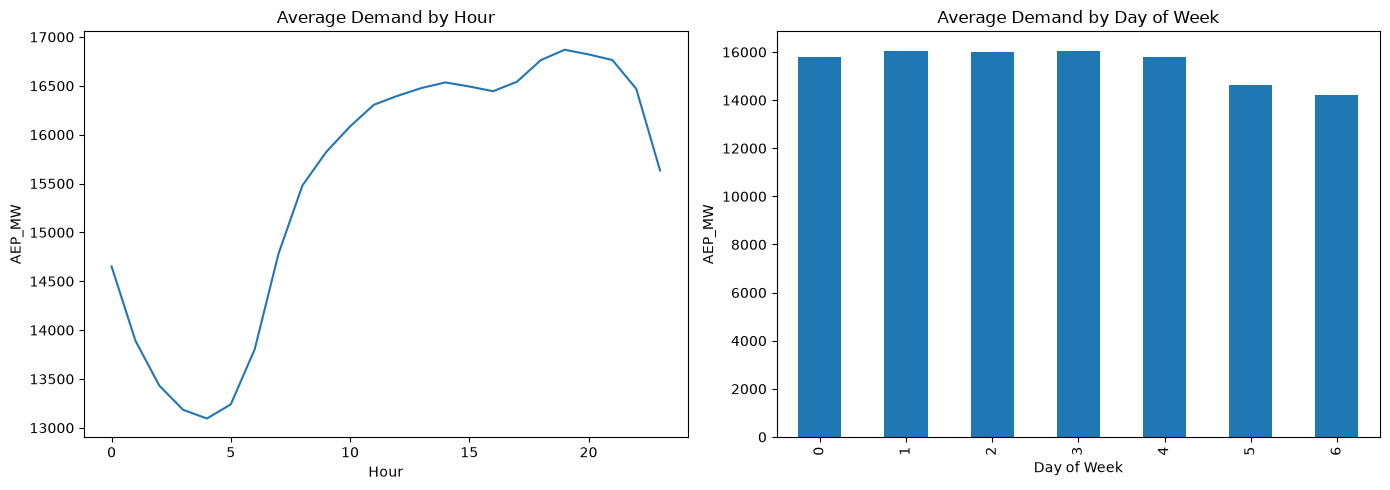

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly_profile.plot(ax=axes[0])
axes[0].set_title("Average Demand by Hour")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("AEP_MW")

daily_profile.plot(kind="bar", ax=axes[1])
axes[1].set_title("Average Demand by Day of Week")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("AEP_MW")

plt.tight_layout()
plt.show()

In [25]:
hourly_profile = df.groupby("hour")["AEP_MW"].mean()
daily_profile = df.groupby("day_of_week")["AEP_MW"].mean()

print("Среднее потребление по часам:")
print(hourly_profile)

print("\nСреднее потребление по дням недели:")
print(daily_profile)

Среднее потребление по часам:
hour
0     14651.191569
1     13891.478433
2     13432.062995
3     13184.049008
4     13095.193350
5     13240.535813
6     13802.401464
7     14781.668381
8     15478.830233
9     15822.653740
10    16084.283934
11    16306.315592
12    16398.177087
13    16477.793035
14    16534.660202
15    16492.810645
16    16444.506134
17    16542.038781
18    16762.940047
19    16868.728334
20    16821.335180
21    16763.806292
22    16468.967550
23    15632.594183
Name: AEP_MW, dtype: float64

Среднее потребление по дням недели:
day_of_week
0    15810.973684
1    16057.615571
2    16013.589739
3    16028.138281
4    15773.123911
5    14610.979628
6    14200.754680
Name: AEP_MW, dtype: float64


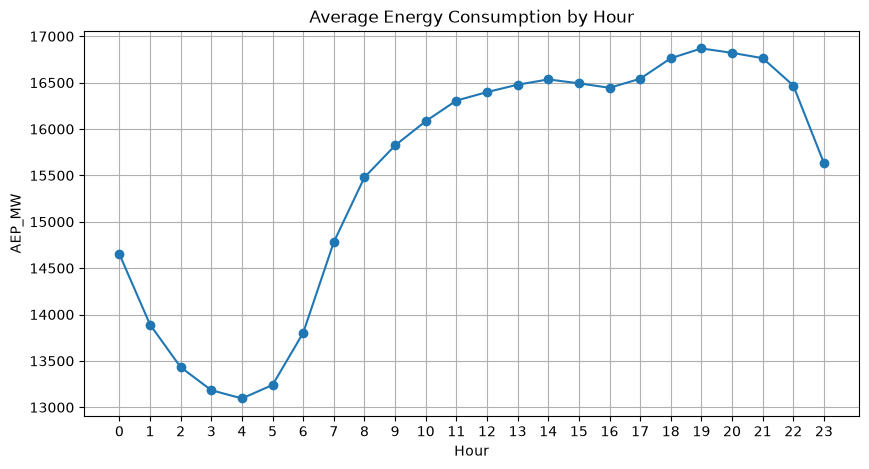

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(hourly_profile.index, hourly_profile.values, marker="o")
plt.title("Average Energy Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("AEP_MW")
plt.xticks(range(24))
plt.grid(True)
plt.show()

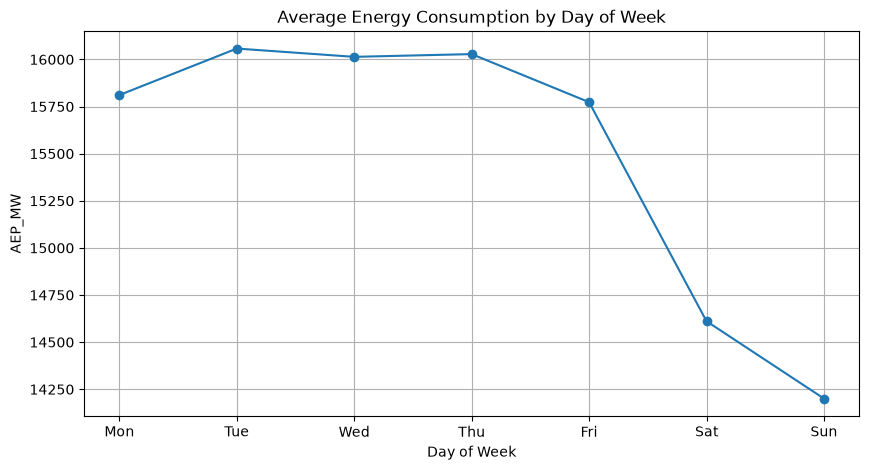

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(daily_profile.index, daily_profile.values, marker="o")
plt.title("Average Energy Consumption by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("AEP_MW")
plt.xticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.grid(True)
plt.show()

In [28]:
print(df.index.min())
print(df.index.max())

print(df.index.to_series().diff().value_counts().head(10))

print("Missing values:", df["AEP_MW"].isna().sum())
print("Duplicates:", df.index.duplicated().sum())

0
121272
1.0    121272
Name: count, dtype: int64
Missing values: 0
Duplicates: 0


In [29]:
print(df["AEP_MW"].describe())

count    121273.000000
mean      15499.513717
std        2591.399065
min        9581.000000
25%       13630.000000
50%       15310.000000
75%       17200.000000
max       25695.000000
Name: AEP_MW, dtype: float64


In [30]:
print("Start:", df.index.min())
print("End:", df.index.max())

print("\nFrequency:")
print(df.index.to_series().diff().value_counts().head(10))

print("\nMissing values:")
print(df["AEP_MW"].isna().sum())

print("\nDuplicate timestamps:")
print(df.index.duplicated().sum())

Start: 0
End: 121272

Frequency:
1.0    121272
Name: count, dtype: int64

Missing values:
0

Duplicate timestamps:
0


In [31]:
print(df.head())
print(df.tail())

             Datetime   AEP_MW  hour  day_of_week
0 2004-10-01 01:00:00  12379.0     1            4
1 2004-10-01 02:00:00  11935.0     2            4
2 2004-10-01 03:00:00  11692.0     3            4
3 2004-10-01 04:00:00  11597.0     4            4
4 2004-10-01 05:00:00  11681.0     5            4
                  Datetime   AEP_MW  hour  day_of_week
121268 2018-08-02 20:00:00  17673.0    20            3
121269 2018-08-02 21:00:00  17303.0    21            3
121270 2018-08-02 22:00:00  17001.0    22            3
121271 2018-08-02 23:00:00  15964.0    23            3
121272 2018-08-03 00:00:00  14809.0     0            4


In [32]:
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime")
df = df.set_index("Datetime")

print(df.index.min())
print(df.index.max())
print(df.index.freq)

2004-10-01 01:00:00
2018-08-03 00:00:00
None
